##### Load dataset

In [45]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [46]:
original_dataset = pd.read_csv("googleplaystore_dataset.csv")
df = original_dataset.copy()

In [47]:
df.shape

(10841, 13)

##### Dataset has:

- 10841 rows
- 13 columns

##### Overview of the dataset 

In [48]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


##### Feature Engineering and Transformation

In [50]:
# Reviews: string -> int

df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

In [51]:
# Installs: "10,000+" -> 10000

df['Installs'] = df['Installs'].astype(str).str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

In [52]:
# Price: "$4.99" -> 4.99

df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [53]:
# Size: "19M" -> 19.0 (MB), "14k" -> 0.014 (MB), "Varies with device" -> NaN

def parse_size(x):
    x = str(x).strip()
    if x in ('Varies with device', 'nan'):
        return np.nan
    if x.endswith('M'):
        return float(x[:-1])
    if x.endswith(('k', 'K')):
        return float(x[:-1]) / 1024.0
    try:
        return float(x)
    except ValueError:
        return np.nan

df['Size_MB'] = df['Size'].apply(parse_size)
df['Size_MB'] = df.groupby('Category')['Size_MB'].transform(lambda s: s.fillna(s.median()))
df['Size_MB'] = df['Size_MB'].fillna(df['Size_MB'].median())

In [54]:
# Dates

df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')
df['Update_Year']  = df['Last Updated'].dt.year
df['Update_Month'] = df['Last Updated'].dt.month
df['Days_Since_Update'] = (df['Last Updated'].max() - df['Last Updated']).dt.days

In [55]:
# New engineered features

df['App_Name_Length']      = df['App'].str.len()
df['Num_Genres']           = df['Genres'].str.split(';').apply(len)
df['Is_Free']              = (df['Type'] == 'Free').astype(int)
df['Reviews_per_Install']  = df['Reviews'] / df['Installs'].replace(0, np.nan)

In [56]:
# Skew-correcting log transforms (Installs, Reviews, Price are heavily right-skewed)

df['Log_Installs'] = np.log1p(df['Installs'])
df['Log_Reviews']  = np.log1p(df['Reviews'])
df['Log_Price']    = np.log1p(df['Price'])

In [57]:
# Binned/categorical versions for plotting & grouping

df['Price_Tier'] = pd.cut(df['Price'], bins=[-0.01, 0, 2, 10, 50, 500],
                           labels=['Free', 'Cheap(0-2)', 'Mid(2-10)', 'Pricey(10-50)', 'Premium(50+)'])
install_bins   = [0, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e10]
install_labels = ['<1K', '1K-10K', '10K-100K', '100K-1M', '1M-10M', '10M-100M', '100M+']
df['Install_Bucket'] = pd.cut(df['Installs'], bins=install_bins, labels=install_labels)

#### Exploratory Data Analysis - charts and insights

In [59]:
# matplotlib and seaborn settings

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

In [61]:
# check the null values 

df.isnull().sum()

App                       0
Category                  0
Rating                 1474
Reviews                   1
Size                      0
Installs                  1
Type                      1
Price                     1
Content Rating            1
Genres                    0
Last Updated              1
Current Ver               8
Android Ver               3
Size_MB                   0
Update_Year               1
Update_Month              1
Days_Since_Update         1
App_Name_Length           0
Num_Genres                0
Is_Free                   0
Reviews_per_Install      16
Log_Installs              1
Log_Reviews               1
Log_Price                 1
Price_Tier                1
Install_Bucket           16
dtype: int64

In [73]:
# drop the null values: 

df.dropna(inplace=True)

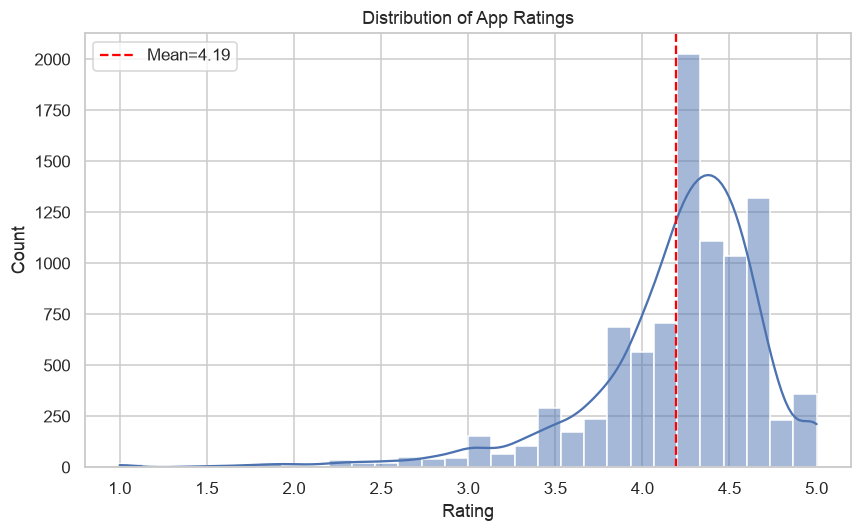

In [76]:
# 1. Distribution of Ratings

plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=30, kde=True, color='#4C72B0')
plt.axvline(df['Rating'].mean(), color='red', linestyle='--', label=f"Mean={df['Rating'].mean():.2f}")
plt.title('Distribution of App Ratings')
plt.xlabel('Rating'); plt.ylabel('Count'); plt.legend()
plt.tight_layout(); 
plt.show()

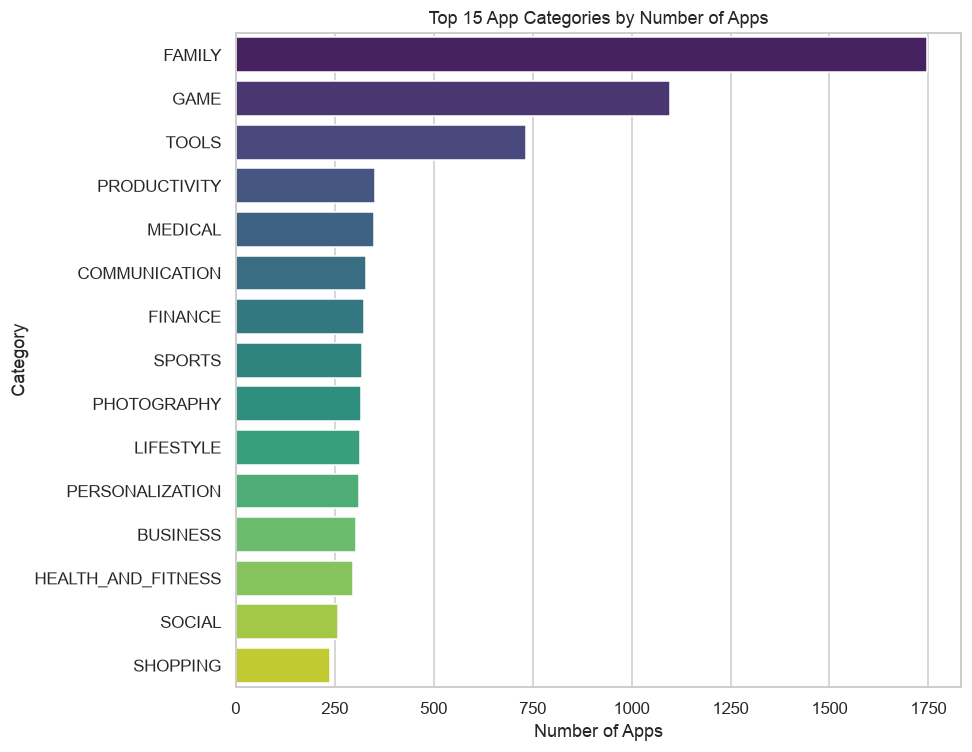

In [78]:
# 2. Top 15 Categories by app count

plt.figure(figsize=(9,7))
cat_counts = df['Category'].value_counts().head(15)
sns.barplot(x=cat_counts.values, y=cat_counts.index, hue=cat_counts.index, palette='viridis', legend=False)
plt.title('Top 15 App Categories by Number of Apps')
plt.xlabel('Number of Apps'); plt.ylabel('Category')
plt.tight_layout()
plt.show()

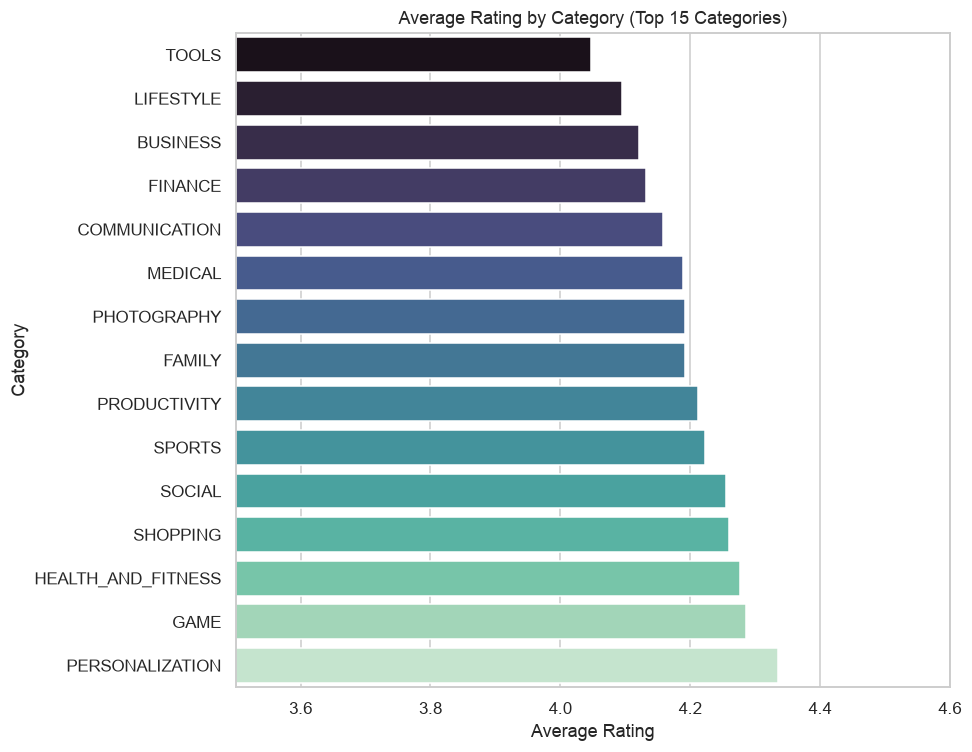

In [79]:
# 3. Average Rating by Category (top 15 by count)

plt.figure(figsize=(9,7))
top_cats = df['Category'].value_counts().head(15).index
avg_rating = df[df['Category'].isin(top_cats)].groupby('Category')['Rating'].mean().sort_values()
sns.barplot(x=avg_rating.values, y=avg_rating.index, hue=avg_rating.index, palette='mako', legend=False)
plt.title('Average Rating by Category (Top 15 Categories)')
plt.xlabel('Average Rating'); plt.ylabel('Category')
plt.xlim(3.5, 4.6)
plt.tight_layout()

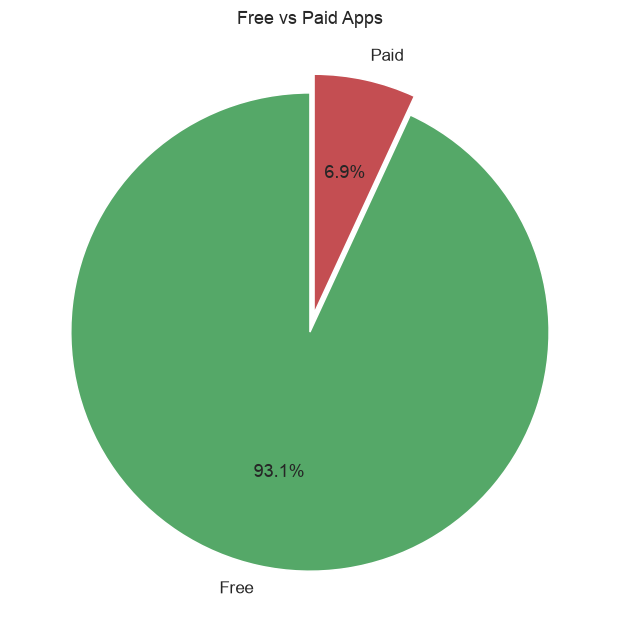

In [80]:
# 4. Free vs Paid count
plt.figure(figsize=(6,6))
type_counts = df['Type'].value_counts()
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#55A868','#C44E52'], startangle=90, explode=[0,0.08])
plt.title('Free vs Paid Apps')
plt.tight_layout()
plt.show()

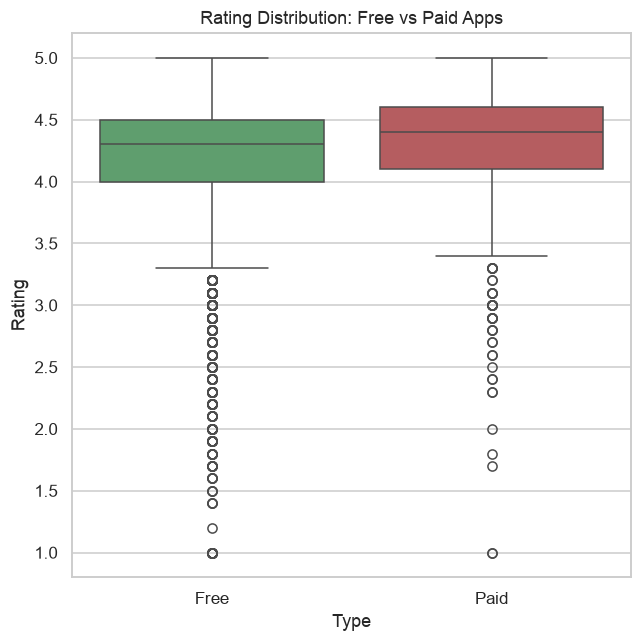

In [86]:
# 5. Rating: Free vs Paid boxplot

plt.figure(figsize=(6,6))
sns.boxplot(data=df, x='Type', y='Rating', hue='Type', palette=['#55A868','#C44E52'], legend=False)
plt.title('Rating Distribution: Free vs Paid Apps')
plt.tight_layout()

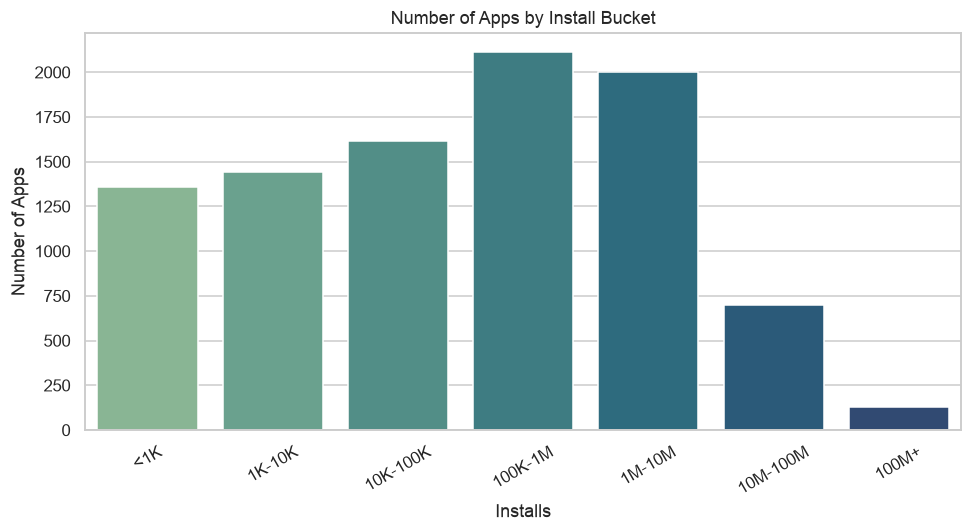

In [81]:
# 6. Installs distribution by bucket

plt.figure(figsize=(9,5))
order = ['<1K','1K-10K','10K-100K','100K-1M','1M-10M','10M-100M','100M+']
inst_counts = df['Install_Bucket'].value_counts().reindex(order)
sns.barplot(x=inst_counts.index, y=inst_counts.values, hue=inst_counts.index, palette='crest', legend=False)
plt.title('Number of Apps by Install Bucket')
plt.xlabel('Installs'); plt.ylabel('Number of Apps'); plt.xticks(rotation=30)
plt.tight_layout()

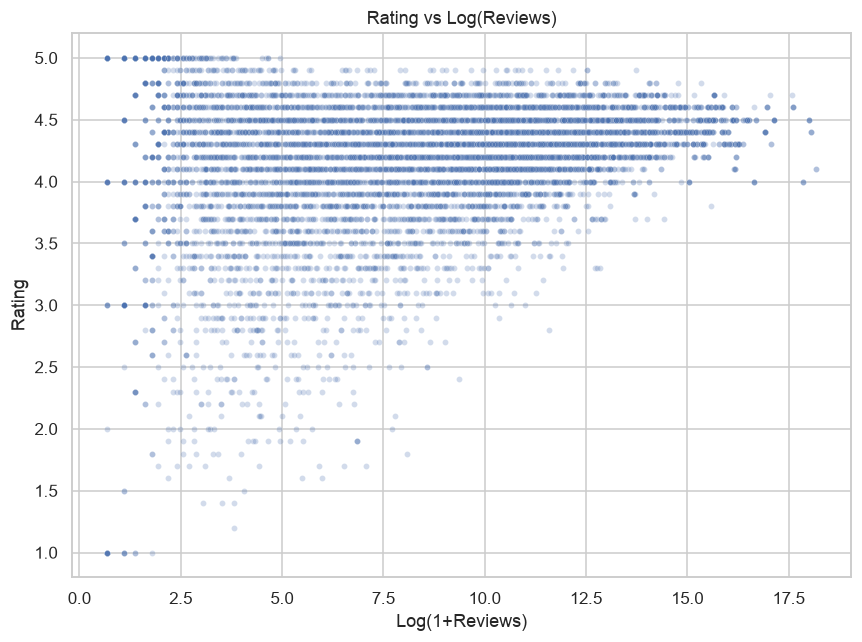

In [84]:
# 7. Reviews vs Rating scatter (log reviews)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Log_Reviews', y='Rating', alpha=0.25, s=15, color='#4C72B0')
plt.title('Rating vs Log(Reviews)')
plt.xlabel('Log(1+Reviews)'); plt.ylabel('Rating')
plt.tight_layout()

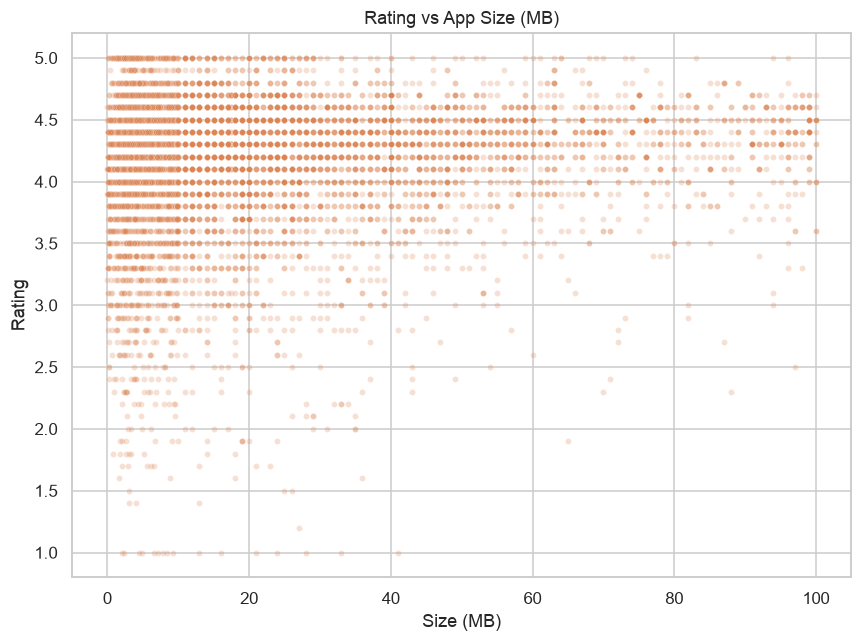

In [85]:
# 8. Size vs Rating scatter

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Size_MB', y='Rating', alpha=0.25, s=15, color='#DD8452')
plt.title('Rating vs App Size (MB)')
plt.xlabel('Size (MB)'); plt.ylabel('Rating')
plt.tight_layout()

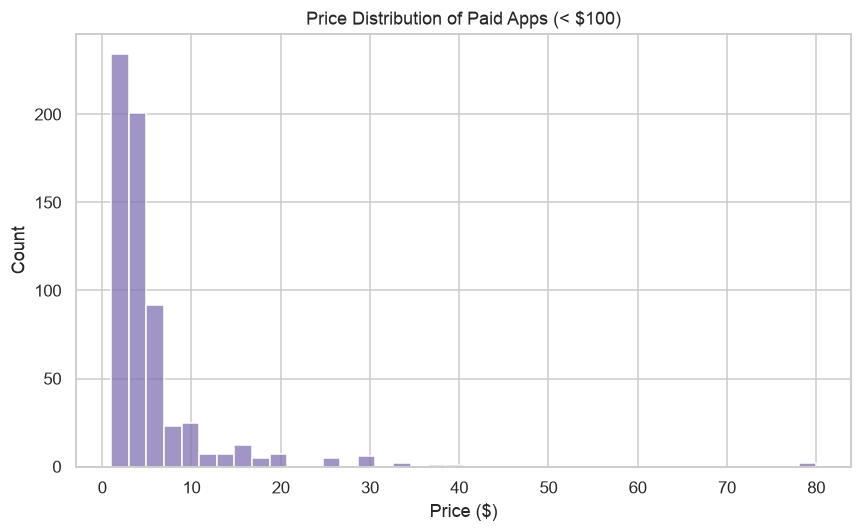

In [87]:
# 9. Price distribution (paid apps only)

plt.figure(figsize=(8,5))
paid = df[(df['Type']=='Paid') & (df['Price']>0) & (df['Price']<100)]
sns.histplot(paid['Price'], bins=40, color='#8172B2')
plt.title('Price Distribution of Paid Apps (< $100)')
plt.xlabel('Price ($)'); plt.ylabel('Count')
plt.tight_layout()

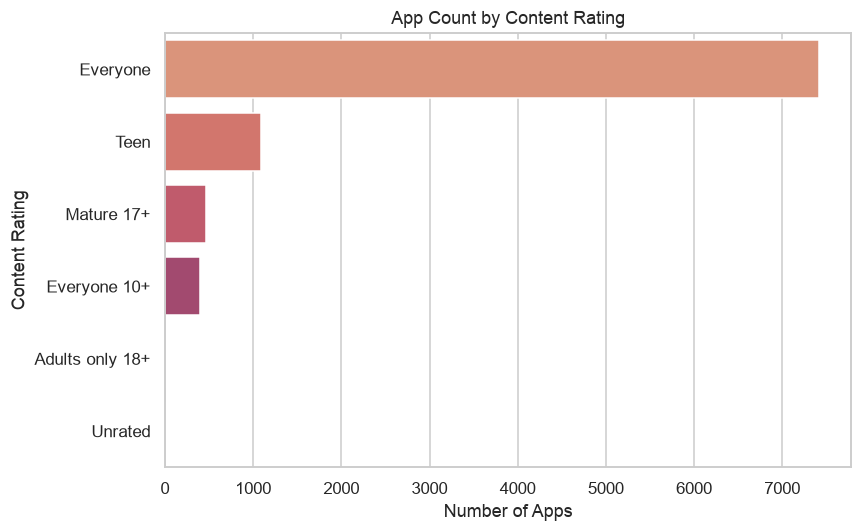

In [88]:
# 10. Content Rating counts

plt.figure(figsize=(8,5))
cr_counts = df['Content Rating'].value_counts()
sns.barplot(x=cr_counts.values, y=cr_counts.index, hue=cr_counts.index, palette='flare', legend=False)
plt.title('App Count by Content Rating')
plt.xlabel('Number of Apps'); plt.ylabel('Content Rating')
plt.tight_layout()
plt.show()